# 函数拟合实验（NumPy实现）

本实验通过 NumPy 实现一个两层 ReLU 神经网络，对自定义函数进行拟合。

In [114]:
# 1. 导入所需库
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子，保证实验可复现
np.random.seed(42)

In [ ]:
# 2. 定义目标函数
def target_function(x):
    # 目标函数：f(x) = sin(pi * x) + cos(pi * x)
    part1 =  np.sin(np.pi * x)
    part2 =  np.cos(np.pi * x)
    return part1 + part2

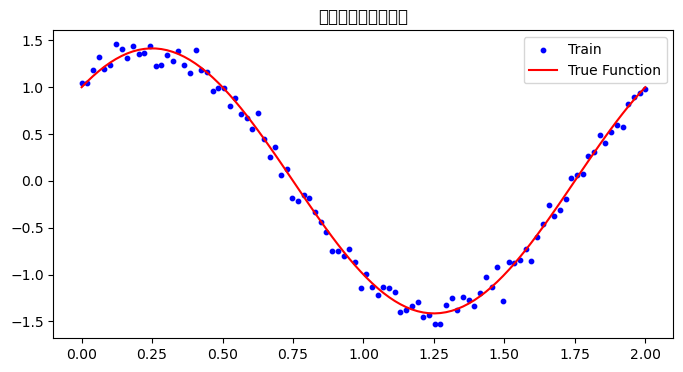

In [116]:
# 3. 生成训练集和测试集
# 在区间[0, 2]上均匀采样
n_train = 100
n_test = 100

x_train = np.linspace(0, 2, n_train)
y_train = target_function(x_train) + 0.1 * np.random.randn(n_train)  # 加入少量噪声

x_test = np.linspace(0, 2, n_test)
y_test = target_function(x_test)

# 可视化采样点
plt.figure(figsize=(8, 4))
plt.scatter(x_train, y_train, label='Train', color='blue', s=10)
plt.plot(x_test, y_test, label='True Function', color='red')
plt.title('目标函数与训练数据')
plt.legend()
plt.show()

In [ ]:
# 4. 定义两层神经网络（NumPy实现）
class TwoLayerReLU:
    def __init__(self, input_dim, hidden_dim, output_dim):
        # 初始化权重和偏置
        self.W1 = np.random.randn(input_dim, hidden_dim)
        self.b1 = np.full(hidden_dim, 0.01)
        self.W2 = np.random.randn(hidden_dim, output_dim)
        self.b2 = np.zeros(output_dim)

    def relu(self, x):
        # ReLU激活函数
        return np.maximum(0, x)

    def relu_grad(self, x):
        # ReLU的梯度
        return (x > 0).astype(float)

    def forward(self, x):
        # 前向传播
        self.z1 = x @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        return self.z2.squeeze()

    def backward(self, x, y, y_pred, lr=0.01):
        # 反向传播
        m = x.shape[0]
        dz2 = (2.0 * (y_pred - y)).reshape(-1, 1) / m  # MSE 对输出层的梯度
        dW2 = self.a1.T @ dz2
        db2 = np.sum(dz2, axis=0)
        da1 = dz2 @ self.W2.T
        dz1 = da1 * self.relu_grad(self.z1)
        dW1 = x.T @ dz1
        db1 = np.sum(dz1, axis=0)

        # 参数更新
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

Epoch 100/10000, Loss: 0.579405
Epoch 200/10000, Loss: 0.311734
Epoch 300/10000, Loss: 0.247102
Epoch 400/10000, Loss: 0.207095
Epoch 500/10000, Loss: 0.177339
Epoch 600/10000, Loss: 0.153897
Epoch 700/10000, Loss: 0.134591
Epoch 800/10000, Loss: 0.118482
Epoch 900/10000, Loss: 0.104867
Epoch 1000/10000, Loss: 0.093154
Epoch 1100/10000, Loss: 0.083142
Epoch 1200/10000, Loss: 0.074550
Epoch 1300/10000, Loss: 0.066987
Epoch 1400/10000, Loss: 0.060421
Epoch 1500/10000, Loss: 0.054735
Epoch 1600/10000, Loss: 0.049725
Epoch 1700/10000, Loss: 0.045357
Epoch 1800/10000, Loss: 0.041507
Epoch 1900/10000, Loss: 0.038192
Epoch 2000/10000, Loss: 0.035300
Epoch 2100/10000, Loss: 0.032750
Epoch 2200/10000, Loss: 0.030445
Epoch 2300/10000, Loss: 0.028394
Epoch 2400/10000, Loss: 0.026574
Epoch 2500/10000, Loss: 0.024981
Epoch 2600/10000, Loss: 0.023572
Epoch 2700/10000, Loss: 0.022324
Epoch 2800/10000, Loss: 0.021213
Epoch 2900/10000, Loss: 0.020213
Epoch 3000/10000, Loss: 0.019319
Epoch 3100/10000, L

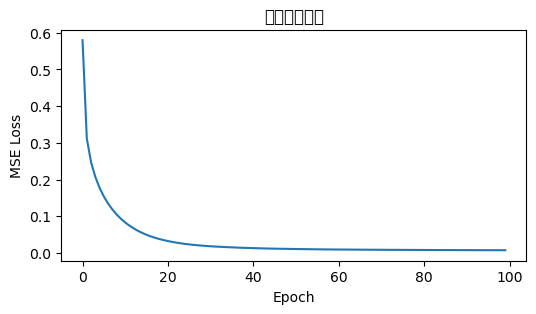

In [118]:
# 5. 训练神经网络
# 超参数
input_dim = 1
hidden_dim = 256
output_dim = 1
learning_rate = 0.005
epochs = 10000

# 数据reshape为二维
x_train_ = x_train.reshape(-1, 1)
x_test_ = x_test.reshape(-1, 1)

# 初始化模型
model = TwoLayerReLU(input_dim, hidden_dim, output_dim)

# 训练过程
losses = []
for epoch in range(epochs):
    y_pred = model.forward(x_train_)
    loss = np.mean((y_pred - y_train) ** 2)

    model.backward(x_train_, y_train, y_pred, lr=learning_rate)

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.6f}")
        losses.append(loss)

# 绘制损失曲线
plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.title('训练损失曲线')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

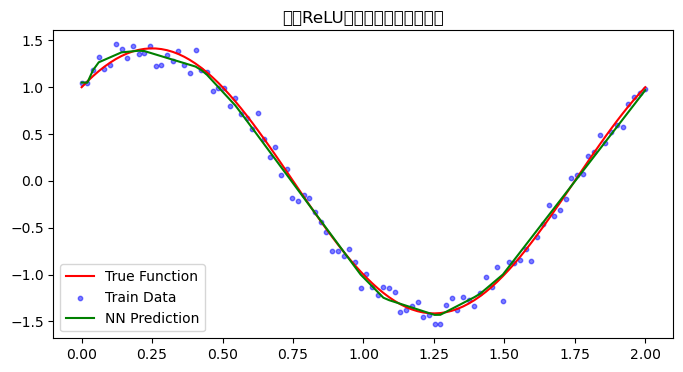

测试集均方误差: 0.0017


In [119]:
# 6. 测试集上的拟合效果
# 预测
pred_test = model.forward(x_test_)

# 绘制拟合结果
plt.figure(figsize=(8, 4))
plt.plot(x_test, y_test, label='True Function', color='red')
plt.scatter(x_train, y_train, label='Train Data', color='blue', s=10, alpha=0.5)
plt.plot(x_test, pred_test, label='NN Prediction', color='green')
plt.title('两层ReLU神经网络函数拟合效果')
plt.legend()
plt.show()

# 计算测试集均方误差
mse_test = np.mean((pred_test - y_test) ** 2)
print(f"测试集均方误差: {mse_test:.4f}")